# Triển khai (Deploy) file `log_history.json`
Notebook này hướng dẫn cách sử dụng file `log_history.json` để kiểm tra lịch sử log và trực quan hóa quá trình huấn luyện mô hình chatbot.

In [21]:
# Đọc và hiển thị nội dung file log_history.json
import json
import os
log_path = '../log_history.json' if not os.path.exists('log_history.json') else 'log_history.json'
with open(log_path, 'r', encoding='utf-8') as f:
    log_data = json.load(f)
print('Số lượng bản ghi log:', len(log_data))
log_data[:3]  # Hiển thị 3 bản ghi đầu tiên

Số lượng bản ghi log: 167


[{'loss': 4.0455,
  'grad_norm': 8.04626178741455,
  'learning_rate': 4.950757575757576e-06,
  'epoch': 1.0,
  'step': 66},
 {'eval_loss': 2.6042916774749756,
  'eval_runtime': 3.8799,
  'eval_samples_per_second': 155.417,
  'eval_steps_per_second': 4.897,
  'epoch': 1.0,
  'step': 66},
 {'loss': 2.5236,
  'grad_norm': 5.081064224243164,
  'learning_rate': 4.900757575757576e-06,
  'epoch': 2.0,
  'step': 132}]

## Ý nghĩa các trường trong `log_history.json`
- `loss`: Giá trị loss trên tập train tại một step/epoch.
- `eval_loss`: Giá trị loss trên tập validation tại một step/epoch.
- `epoch`: Số thứ tự epoch.
- `step`: Số step tương ứng.
- Các trường khác: Thông tin về learning rate, grad_norm, thời gian, tốc độ, v.v.

## Trực quan hóa loss train/val từ log_history.json
Chúng ta sẽ trích xuất các giá trị loss (train/val) từ file log_history.json và trực quan hóa chúng để theo dõi quá trình huấn luyện.

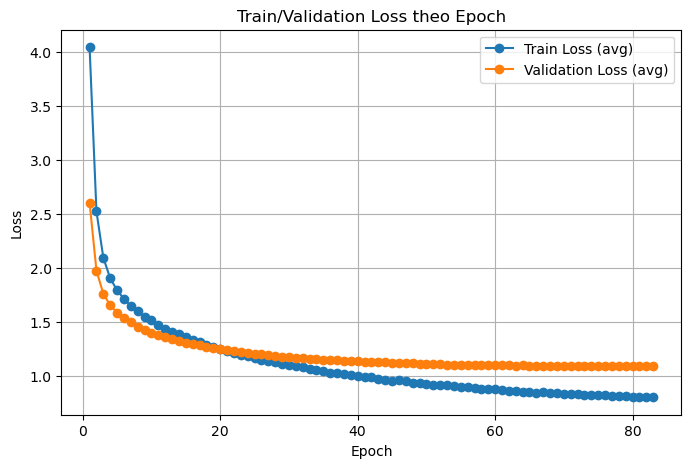

In [22]:
# Trực quan hóa loss (train) và eval_loss (val) theo epoch từ log_history.json
import matplotlib.pyplot as plt
from collections import defaultdict
train_epoch_loss = defaultdict(list)
val_epoch_loss = defaultdict(list)
for entry in log_data:
    if 'loss' in entry and 'epoch' in entry:
        train_epoch_loss[entry['epoch']].append(entry['loss'])
    if 'eval_loss' in entry and 'epoch' in entry:
        val_epoch_loss[entry['epoch']].append(entry['eval_loss'])
# Lấy giá trị trung bình loss cho mỗi epoch
epochs = sorted(set(list(train_epoch_loss.keys()) + list(val_epoch_loss.keys())))
train_loss_avg = [sum(train_epoch_loss[e])/len(train_epoch_loss[e]) if train_epoch_loss[e] else None for e in epochs]
val_loss_avg = [sum(val_epoch_loss[e])/len(val_epoch_loss[e]) if val_epoch_loss[e] else None for e in epochs]
plt.figure(figsize=(8,5))
if any(train_loss_avg):
    plt.plot(epochs, train_loss_avg, marker='o', label='Train Loss (avg)')
if any(val_loss_avg):
    plt.plot(epochs, val_loss_avg, marker='o', label='Validation Loss (avg)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/Validation Loss theo Epoch')
plt.legend()
plt.grid(True)
plt.show()